In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

#### NOTE
For association analysis, we only work with the articles which had a full-text!

In [2]:
drug_col = "merged_umls_label"
disease_col = "merged_mondo_label"

# Prep Clinical Trials

In [3]:
clin_entities_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_clin.csv"
df_clin_entities = pd.read_csv(clin_entities_file)
df_clin_entities.head()

,nct_id,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid
0,NCT03502551,suicidal|suicidal ideation|Suicide,suicidal|suicidal ideation|Suicide,-1|-1|-1,suicidal|suicidal ideation|Suicide,-1,suicidal|suicidal ideation|Suicide,-1|-1|-1,ketamine,Ketamine,C0022614,-1,Ketamine,C0022614
1,NCT05216770,laryngeal dystonia|voice tremor|Tremor,spasmodic dystonia|voice tremor|obsolete rare ...,MONDO:0000485|-1|MONDO:0017644,spasmodic dystonia|voice tremor|obsolete rare ...,focal dystonia|-1,spasmodic dystonia|voice tremor|obsolete rare ...,MONDO:0000485|-1|MONDO:0017644|MONDO:0000477,Laryngeal sensory block with topical bupivacaine,Laryngeal sensory block with topical bupivacaine,-1,-1,Laryngeal sensory block with topical bupivacaine,-1
2,NCT03348735,np|subacute|pain|localized neuropathic pain|ch...,np|subacute|obsolete disorder involving pain|l...,-1|-1|MONDO:0021668|-1|MONDO:0021667|MONDO:002...,np|subacute|obsolete disorder involving pain|l...,-1|-1,np|subacute|obsolete disorder involving pain|l...,-1|-1|MONDO:0021668|-1|MONDO:0021667,lidocaine|capsaicin|Lidocaine patch 5%,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,C0023660|C0006931|C0794811,-1,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,C0023660|C0006931|C0794811
3,NCT05995600,systemic lupus|definite|antiphospholipid syndr...,systemic lupus erythematosus|definite|antiphos...,MONDO:0007915|-1|-1|MONDO:0005098|-1|MONDO:000...,systemic lupus erythematosus|definite|antiphos...,-1|-1|-1|-1|-1|brain ischemia,systemic lupus erythematosus|definite|antiphos...,MONDO:0007915|-1|-1|MONDO:0005098|-1|MONDO:000...,clopidogrel|warfarin|aspirin|Antiplatelet Drug,clopidogrel|Warfarin|Aspirin|Antiplatelet Drug,C0070166|C0043031|C0004057|-1,-1,clopidogrel|Warfarin|Aspirin|Antiplatelet Drug,C0070166|C0043031|C0004057|-1
4,NCT02137993,schizophreniform disorder|schizoaffective diso...,schizophreniform disorder|schizophrenia|schizo...,MONDO:0001265|MONDO:0005090|MONDO:0005090,schizophreniform disorder|schizophrenia,-1|-1,schizophreniform disorder|schizophrenia,MONDO:0001265|MONDO:0005090,zyprexa|A-prexa,Zyprexa|A-prexa,C0527258|-1,olanzapine pamoate|OLANZapine|olanzapine pamoa...,Zyprexa|A-prexa|olanzapine pamoate|OLANZapine|...,C0527258|-1|C2698647|C0171023|C2726929


In [4]:
df_clin_entities.shape


(18609, 14)

In [5]:
clin_metadata_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/06_preclin_clinic_join/data/clinical/clinical_nct_docs_metadata_20240313.csv"
df_clin_metadata = pd.read_csv(clin_metadata_file)
df_clin_metadata = df_clin_metadata.drop_duplicates(subset=['nct_id'])

df_clin_metadata.head()

,nct_id,Neurological Disease,Disease Class,brief_title,study_official_title,brief_summary_description,start_date,completion_date,phase,study_type,overall_status,country_name,intervention_name,intervention_type
0,NCT03890861,"Dementia, Alzheimer Type",Neurodegenerative Diseases,Reducing African Americans' Alzheimer's Diseas...,Reducing African Americans' Alzheimer's Diseas...,The RAATE proposal is designed to determine th...,2019-08-09,2026-11-30,Not Applicable,Interventional,Recruiting,United States,Physical activity,Behavioral
6,NCT03060096,Depressive Symptoms,Psychiatry and Psychology Category,Stepped-Care Telehealth for Distress in Cancer...,Stepped-Care Telehealth for Distress in Cancer...,Mental health issues in post-treatment adult c...,2018-07-19,2023-12-31,Not Applicable,Interventional,Completed,United States,Severe Anxiety/depression: High Intensity Step...,Other
12,NCT04525742,Muscular Dystrophies,Neuromuscular Diseases,COVID-19 Pandemic and Parents of Disabled Chil...,COVID-19 Pandemic From the Perspective of Pare...,Pandemic period could affect the disabled chil...,2020-07-05,2020-09-15,Not Applicable,Interventional,Completed,Turkey,Difficulties lived by disabled children's pare...,Other
15,NCT02324634,Stroke,Central Nervous System Diseases,Early Electrical Stimulation to Prevent Compli...,Early Electrical Stimulation to the Wrist Exte...,Stroke is the largest cause of adult disabilit...,2015-06-01,2017-11-30,Not Applicable,Interventional,Unknown status,United Kingdom,NeuroTrac Rehab dual channel device,Device
18,NCT06036368,Essential Tremor,Central Nervous System Diseases,Study to Evaluate Safety and Efficacy of Peron...,"6-weeks, Open-label, Single-Site Study to Eval...","This is a 6-week exploratory clinical study, d...",2023-09-15,2024-06-30,Not Applicable,Interventional,Not yet recruiting,Czechia,Peroneal electrical transcutaneous neuromodula...,Device


In [6]:
df_clin_metadata.shape

(46376, 14)

In [7]:
df_clin_entities_metadata = df_clin_entities.merge(df_clin_metadata, on="nct_id", how="left")[['nct_id',drug_col,disease_col, 'start_date', 'completion_date', 'overall_status', 'phase']]
df_clin_entities_metadata.head()

,nct_id,merged_umls_label,merged_mondo_label,start_date,completion_date,overall_status,phase
0,NCT03502551,Ketamine,suicidal|suicidal ideation|Suicide,2019-04-01,2019-06-30,Withdrawn,Phase 2
1,NCT05216770,Laryngeal sensory block with topical bupivacaine,spasmodic dystonia|voice tremor|obsolete rare ...,2022-03-24,2026-08-31,Recruiting,Early Phase 1
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4
3,NCT05995600,clopidogrel|Warfarin|Aspirin|Antiplatelet Drug,systemic lupus erythematosus|definite|antiphos...,2023-12-31,2028-08-31,Not yet recruiting,Phase 4
4,NCT02137993,Zyprexa|A-prexa|olanzapine pamoate|OLANZapine|...,schizophreniform disorder|schizophrenia,2012-03-31,2013-05-31,Completed,Phase 4


In [8]:
list(df_clin_entities_metadata[df_clin_entities_metadata['nct_id']=='NCT00383448'].merged_umls_label)

['Mofetil, Mycophenolate|Infecto Flu|Monomethyl fumarate|clofarabine']

### flatten drug/ disease

In [9]:
df_clin_entities_metadata_flat_drug = (
    df_clin_entities_metadata
    .assign(merged_umls_label_flat=df_clin_entities_metadata[drug_col].astype(str).str.split("|"))
    .explode("merged_umls_label_flat")
)

In [10]:
df_clin_entities_metadata_flat_drug.head()

,nct_id,merged_umls_label,merged_mondo_label,start_date,completion_date,overall_status,phase,merged_umls_label_flat
0,NCT03502551,Ketamine,suicidal|suicidal ideation|Suicide,2019-04-01,2019-06-30,Withdrawn,Phase 2,Ketamine
1,NCT05216770,Laryngeal sensory block with topical bupivacaine,spasmodic dystonia|voice tremor|obsolete rare ...,2022-03-24,2026-08-31,Recruiting,Early Phase 1,Laryngeal sensory block with topical bupivacaine
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,Lidocaine
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,Capsaicin
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,lidocaine 0.05 MG/MG Medicated Patch


In [11]:
df_clin_entities_metadata_flat_drug.merged_umls_label_flat.nunique()

12904

In [12]:
# Ensure date columns are in datetime format
df_clin_entities_metadata_flat_drug["start_date"] = pd.to_datetime(
    df_clin_entities_metadata_flat_drug["start_date"], errors="coerce"
)
df_clin_entities_metadata_flat_drug["completion_date"] = pd.to_datetime(
    df_clin_entities_metadata_flat_drug["completion_date"], errors="coerce"
)

# Compute duration in days
df_clin_entities_metadata_flat_drug["trial_duration_days"] = (
    df_clin_entities_metadata_flat_drug["completion_date"]
    - df_clin_entities_metadata_flat_drug["start_date"]
).dt.days

# Remove negative or invalid durations
df_clin_entities_metadata_flat_drug.loc[
    df_clin_entities_metadata_flat_drug["trial_duration_days"] < 0,
    "trial_duration_days"
] = np.nan

# Convert to years (rounded to 2 decimals)
df_clin_entities_metadata_flat_drug["trial_duration_years"] = (
    df_clin_entities_metadata_flat_drug["trial_duration_days"] / 365.25
).round(2)

In [13]:
df_clin_entities_metadata_flat_drug.head()

,nct_id,merged_umls_label,merged_mondo_label,start_date,completion_date,overall_status,phase,merged_umls_label_flat,trial_duration_days,trial_duration_years
0,NCT03502551,Ketamine,suicidal|suicidal ideation|Suicide,2019-04-01,2019-06-30,Withdrawn,Phase 2,Ketamine,90.0,0.25
1,NCT05216770,Laryngeal sensory block with topical bupivacaine,spasmodic dystonia|voice tremor|obsolete rare ...,2022-03-24,2026-08-31,Recruiting,Early Phase 1,Laryngeal sensory block with topical bupivacaine,1621.0,4.44
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,Lidocaine,868.0,2.38
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,Capsaicin,868.0,2.38
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,lidocaine 0.05 MG/MG Medicated Patch,868.0,2.38


In [60]:
def phase_to_num(s: str) -> float:
    """
    Map phase strings (Arabic only) to numeric ranks:
      Not Applicable / Observational -> 0.0
      Early Phase 1 / Phase 0       -> 0.75
      Phase x                       -> x.0
      Phase x/y                     -> (min(x,y) + 0.5)
      Phase 2a/b                    -> 2.0 (treat a/b as that phase)
    Unknown/missing -> NaN
    """
    if not isinstance(s, str) or not s.strip():
        return np.nan
    t = s.strip()

    if re.search(r"not\s*applicable|observational", t, re.I):
        return 0.0
    if re.search(r"early\s*phase\s*1|phase\s*0", t, re.I):
        return 0.75

    nums = [int(x) for x in re.findall(r"Phase\s*([0-4])(?:\s*[abAB])?", t, flags=re.I)]
    if len(nums) >= 2:
        a, b = sorted(nums[:2])
        return a + 0.5
    if len(nums) == 1:
        return float(nums[0])

    return np.nan


def prepare_exploded_trials(
    df: pd.DataFrame,
    drug_col: str,
    nct_col: str,
    date_col: str,
    phase_col: str,
    duration_col: str,
    status_col: str,
) -> pd.DataFrame:
    """Select needed columns, explode pipe-separated drugs, parse dates, and add helpers."""
    cols = [c for c in [nct_col, drug_col, date_col, phase_col, duration_col, status_col] if c in df.columns]
    w = df[cols].copy()

    # explode pipe-separated drugs
    w = w[w[drug_col].notna()].copy()
    w[drug_col] = w[drug_col].astype(str).str.split("|")
    w = w.explode(drug_col, ignore_index=True)
    w[drug_col] = w[drug_col].astype(str).str.strip()
    w = w[(w[drug_col] != "") & (w[drug_col].str.lower() != "nan")].copy()

    # parse dates
    if date_col in w.columns:
        w[date_col] = pd.to_datetime(w[date_col], errors="coerce")
        w["start_year"] = w[date_col].dt.year
    else:
        w["start_year"] = np.nan

    # phase numeric helper
    if phase_col in w.columns:
        w["phase_num"] = w[phase_col].apply(phase_to_num)
    else:
        w["phase_num"] = np.nan

    return w


def compute_duration_stats(
    w: pd.DataFrame,
    drug_col: str,
    nct_col: str,
    date_col: str,
    duration_col: str,
    status_col: str,
) -> tuple[pd.Series, pd.DataFrame, pd.DataFrame]:
    """Median duration, shortest COMPLETED, and longest (any status)."""
    if duration_col not in w.columns:
        median_duration = pd.Series(dtype=float, name="median_trial_duration_years")
        shortest_info = pd.DataFrame(columns=[drug_col, "shortest_trial_nct_id", "shortest_trial_years"])
        longest_info = pd.DataFrame(columns=[drug_col, "longest_trial_nct_id", "longest_trial_years"])
        return median_duration, shortest_info, longest_info

    median_duration = w.groupby(drug_col)[duration_col].median().rename("median_trial_duration_years")

    # Shortest among completed
    completed_mask = (
        w[status_col].astype(str).str.strip().str.lower().eq("completed")
        if status_col in w.columns else pd.Series(True, index=w.index)
    )
    w_completed = w[completed_mask & w[duration_col].notna()].copy()

    sort_cols_short = [drug_col, duration_col] + ([date_col] if date_col in w.columns else [])
    shortest_info = (
        w_completed
        .sort_values(sort_cols_short, ascending=True)
        .drop_duplicates(subset=[drug_col], keep="first")
        [[drug_col, nct_col, duration_col]]
        .rename(columns={nct_col: "shortest_trial_nct_id", duration_col: "shortest_trial_years"})
    ) if nct_col in w.columns else pd.DataFrame(columns=[drug_col, "shortest_trial_nct_id", "shortest_trial_years"])

    # Longest among all statuses
    w_dur = w.dropna(subset=[duration_col]).copy()
    sort_cols_long = [drug_col, duration_col] + ([date_col] if date_col in w.columns else [])
    ascending_long = [True, False] + ([True] if date_col in w.columns else [])
    longest_info = (
        w_dur
        .sort_values(sort_cols_long, ascending=ascending_long)
        .drop_duplicates(subset=[drug_col], keep="first")
        [[drug_col, nct_col, duration_col]]
        .rename(columns={nct_col: "longest_trial_nct_id", duration_col: "longest_trial_years"})
    ) if nct_col in w.columns else pd.DataFrame(columns=[drug_col, "longest_trial_nct_id", "longest_trial_years"])

    return median_duration, shortest_info, longest_info


def compute_phase_stats(
    w: pd.DataFrame,
    drug_col: str,
    nct_col: str,
    date_col: str,
    phase_col: str,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Min phase (>0), max phase, and earliest trial (ties: higher phase_num)."""
    # Defaults
    min_info = pd.DataFrame(columns=[drug_col, "min_phase_nct_id", "min_phase", "min_phase_start_year"])
    max_info = pd.DataFrame(columns=[drug_col, "max_phase_nct_id", "max_phase", "max_phase_start_year"])
    earliest_info = pd.DataFrame(columns=[drug_col, "earliest_trial_nct_id", "earliest_trial_phase", "earliest_trial_start_year"])

    if (phase_col not in w.columns) or (nct_col not in w.columns):
        return min_info, max_info, earliest_info

    # Max phase: keep earliest start if tie
    valid_max = w[w["phase_num"].notna()].copy()
    if not valid_max.empty:
        max_ties = valid_max.loc[
            valid_max.groupby(drug_col)["phase_num"].transform("max").eq(valid_max["phase_num"])
        ]
        sort_cols = [drug_col] + ([date_col] if date_col in w.columns else [])
        max_info = (
            max_ties
            .sort_values(sort_cols)
            .drop_duplicates(subset=[drug_col])
            [[drug_col, nct_col, phase_col, "start_year"]]
            .rename(columns={nct_col: "max_phase_nct_id", phase_col: "max_phase", "start_year": "max_phase_start_year"})
        )

    # Min phase: ignore <= 0.0 (Not Applicable)
    valid_min = w[(w["phase_num"].notna()) & (w["phase_num"] > 0.0)].copy()
    if not valid_min.empty:
        min_ties = valid_min.loc[
            valid_min.groupby(drug_col)["phase_num"].transform("min").eq(valid_min["phase_num"])
        ]
        sort_cols = [drug_col] + ([date_col] if date_col in w.columns else [])
        min_info = (
            min_ties
            .sort_values(sort_cols)
            .drop_duplicates(subset=[drug_col])
            [[drug_col, nct_col, phase_col, "start_year"]]
            .rename(columns={nct_col: "min_phase_nct_id", phase_col: "min_phase", "start_year": "min_phase_start_year"})
        )

    # Earliest trial overall: ties -> highest phase_num
    if date_col in w.columns:
        earliest_info = (
            w.dropna(subset=[date_col])
             .sort_values([drug_col, date_col, "phase_num"], ascending=[True, True, False])
             .drop_duplicates(subset=[drug_col], keep="first")
             [[drug_col, nct_col, phase_col, "start_year"]]
             .rename(columns={
                 nct_col: "earliest_trial_nct_id",
                 phase_col: "earliest_trial_phase",
                 "start_year": "earliest_trial_start_year"
             })
        )

    return min_info, max_info, earliest_info


def compute_flags(
    w: pd.DataFrame,
    drug_col: str,
    phase_col: str,
    status_col: str,
) -> pd.DataFrame:
    """Drug-level boolean flags from exploded rows."""
    idx = w[drug_col] if drug_col in w.columns else pd.Series([], dtype=object)

    if phase_col in w.columns:
        at_least_one_phase4 = (
            w[phase_col].astype(str).str.contains(r"\bPhase\s*4\b", case=False, na=False)
            .groupby(idx).any()
            .rename("at_least_one_phase4")
        )
    else:
        at_least_one_phase4 = pd.Series(dtype=bool, name="at_least_one_phase4")

    if (phase_col in w.columns) and (status_col in w.columns):
        at_least_one_phase3_completed = (
            (
                w[phase_col].astype(str).str.contains(r"\bPhase\s*3\b", case=False, na=False)
                & w[status_col].astype(str).str.strip().str.lower().eq("completed")
            )
            .groupby(idx).any()
            .rename("at_least_one_phase3_completed")
        )
    else:
        at_least_one_phase3_completed = pd.Series(dtype=bool, name="at_least_one_phase3_completed")

    return pd.concat([at_least_one_phase3_completed, at_least_one_phase4], axis=1)


def summarize_trials_by_drug_simple(
    df: pd.DataFrame,
    drug_col: str = "drug_term_umls_norm",
    nct_col: str = "nct_id",
    date_col: str = "start_date",
    phase_col: str = "phase",
    duration_col: str = "trial_duration_years",
    status_col: str = "overall_status",
) -> pd.DataFrame:
    """
    Orchestrator: prepare exploded rows, compute aggregates, then assemble per-drug summary.
    """
    w = prepare_exploded_trials(df, drug_col, nct_col, date_col, phase_col, duration_col, status_col)

    # n trials
    n_trials = (
        w.groupby(drug_col)[nct_col].nunique().rename("n_unique_trials")
        if nct_col in w.columns else w.groupby(drug_col).size().rename("n_unique_trials")
    )

    # pieces
    median_duration, shortest_info, longest_info = compute_duration_stats(
        w, drug_col, nct_col, date_col, duration_col, status_col
    )
    min_info, max_info, earliest_info = compute_phase_stats(
        w, drug_col, nct_col, date_col, phase_col
    )
    flags = compute_flags(w, drug_col, phase_col, status_col)

    # assemble (join on index, merge where needed)
    out = (
        n_trials.to_frame()
        .join(median_duration, how="left")
        .join(flags, how="left")
        .reset_index()
        .merge(min_info, on=drug_col, how="left")
        .merge(max_info, on=drug_col, how="left")
        .merge(earliest_info, on=drug_col, how="left")
        .merge(shortest_info, on=drug_col, how="left")
        .merge(longest_info, on=drug_col, how="left")
        .rename(columns={drug_col: "drug_term_umls_norm"})
        .sort_values(
            ["max_phase_start_year", "max_phase", "n_unique_trials"],
            ascending=[True, False, False],
            na_position="last",
        )
    )

    # tidy booleans + durations
    for c in ["at_least_one_phase3_completed", "at_least_one_phase4"]:
        if c in out.columns:
            out[c] = out[c].fillna(False).astype(bool)

    for c in ["median_trial_duration_years", "shortest_trial_years", "longest_trial_years"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce").round(2)

    return out


#### clinical details 

In [66]:
### maybe take this from Translation_01_Drug??? similar process
clinical_drug_summary = summarize_trials_by_drug_simple(df_clin_entities_metadata_flat_drug, drug_col="merged_umls_label_flat")
clinical_drug_summary.head()

,drug_term_umls_norm,n_unique_trials,median_trial_duration_years,at_least_one_phase3_completed,at_least_one_phase4,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,max_phase_start_year,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years
5365,PLACEBO,330,2.00,True,True,NCT02102113,Early Phase 1,2014.0,NCT00659919,Phase 4,2000,NCT00006289,Phase 2,2000,NCT03783312,0.14,NCT00676715,15.31
6128,Risperidone,295,2.25,True,True,NCT03790085,Early Phase 1,2018.0,NCT00469664,Phase 4,2000,NCT00249223,Phase 3,2000,NCT00645502,0.08,NCT02535156,12.00
5091,OLANZapine,226,2.33,True,True,NCT00287352,Phase 1,2005.0,NCT00469664,Phase 4,2000,NCT00469664,Phase 4,2000,NCT02804568,0.17,NCT00512070,18.42
629,ARIPiprazole,219,2.50,True,True,NCT00089440,Phase 1,2004.0,NCT00469664,Phase 4,2000,NCT00041678,Phase 3,2000,NCT01552772,0.25,NCT00320671,10.00
5884,QUEtiapine,196,2.25,True,True,NCT04280965,Early Phase 1,2019.0,NCT00469664,Phase 4,2000,NCT00469664,Phase 4,2000,NCT05793632,0.12,NCT00297947,9.83


In [67]:
clinical_drug_summary[clinical_drug_summary["drug_term_umls_norm"].str.contains("xarelto", case=False, na=False)].head()

,drug_term_umls_norm,n_unique_trials,median_trial_duration_years,at_least_one_phase3_completed,at_least_one_phase4,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,max_phase_start_year,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years
6153,"Rivaroxaban (Xarelto, BAY59-7939)",1,3.15,False,False,NCT02313909,Phase 3,2014.0,NCT02313909,Phase 3,2014,NCT02313909,Phase 3,2014,NaN,NaN,NCT02313909,3.15
7409,Xarelto,2,1.46,False,True,NCT02042534,Phase 2,2014.0,NCT02970773,Phase 4,2017,NCT02042534,Phase 2,2014,NCT02042534,1.91,NCT02042534,1.91


In [68]:
clinical_drug_summary.tail()

,drug_term_umls_norm,n_unique_trials,median_trial_duration_years,at_least_one_phase3_completed,at_least_one_phase4,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,max_phase_start_year,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years
10120,kl,1,3.08,False,False,NCT05882487,Early Phase 1,2023.0,NCT05882487,Early Phase 1,2023,NCT05882487,Early Phase 1,2023,NaN,NaN,NCT05882487,3.08
10121,kl002,1,3.08,False,False,NCT05882487,Early Phase 1,2023.0,NCT05882487,Early Phase 1,2023,NCT05882487,Early Phase 1,2023,NaN,NaN,NCT05882487,3.08
10549,methyl prednisone,1,0.14,False,False,NCT06025097,Early Phase 1,2023.0,NCT06025097,Early Phase 1,2023,NCT06025097,Early Phase 1,2023,NCT06025097,0.14,NCT06025097,0.14
11151,oral anti-Parkinson drugs and injection of bot...,1,2.85,False,False,NCT05997043,Early Phase 1,2023.0,NCT05997043,Early Phase 1,2023,NCT05997043,Early Phase 1,2023,NaN,NaN,NCT05997043,2.85
11730,rifaximin 200 MG,1,2.65,False,False,NCT05786859,Early Phase 1,2023.0,NCT05786859,Early Phase 1,2023,NCT05786859,Early Phase 1,2023,NaN,NaN,NCT05786859,2.65


<Axes: >

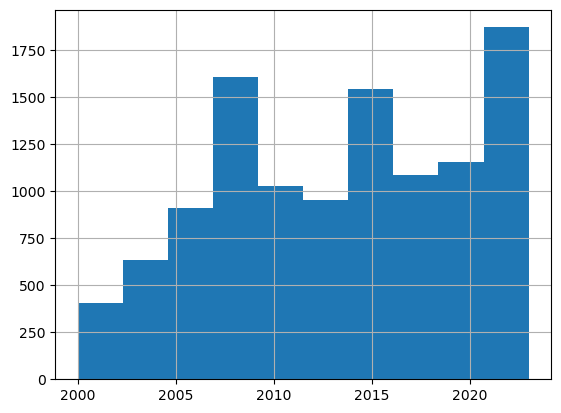

In [69]:
clinical_drug_summary.min_phase_start_year.hist()

<Axes: >

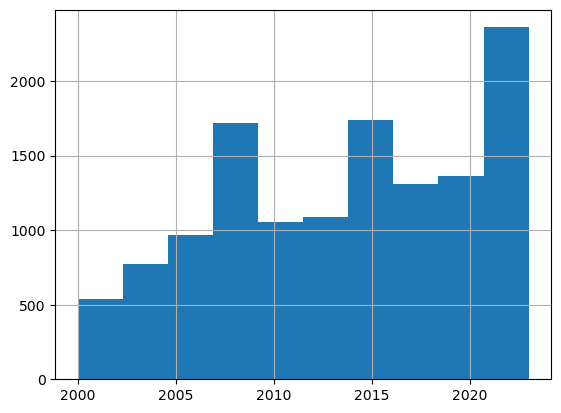

In [70]:
clinical_drug_summary.max_phase_start_year.hist()

In [71]:
clinical_drug_summary.to_csv("out/all_drugs_clinical_min_max_phase.csv")

# Prep Preclinical Articles

In [72]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

df_path_current_dataset = f"{base_annotation_dir}/full_text_combined_all_annotations_metadata.csv" # FROM /09_corpus_analysis/01_Prep_Annotations.ipynb
# TODO: issue with animal_age
preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title',disease_col, drug_col, 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_strain','animal_number', 'assay_type', 'first_author_country']]
preclin_dataset['animal_sex'] = preclin_dataset['animal_sex'].apply(lambda x:x.replace("sex-",""))
preclin_dataset.head()


/tmp/ipykernel_4068986/3454920442.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title',disease_col, drug_col, 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_strain','animal_number', 'assay_type', 'first_author_country']]


,PMID,title,merged_mondo_label,merged_umls_label,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country
0,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,not reported,unlabeled
1,1000338,A morphometric investigation of the duodenal m...,vitamin D deficiency,VITAMIN D,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,not reported,not reported,"Histology, Molecular & Cellular",unlabeled
2,10021294,Effects of IL-12 on human ovarian tumors engra...,ovarian carcinoma|ovarian neoplasm,"Il12a protein, mouse|Interleukin 12|Edodekin a...",blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,45.0,not reported,USA
3,10021348,Mechanisms of GDF-5 action during skeletal dev...,obsolete cartilage disease,Growth Differentiation Factor 5,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,"Histology, Molecular & Cellular",UK
4,10022166,Prenatal vitamin E treatment improves lung gro...,congenital diaphragmatic hernia,Vitamin E,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,female,Sprague-Dawley,not reported,"Histology, Molecular & Cellular",USA


In [73]:
#primekg_cleaned = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv")
#preclin_dataset = preclin_dataset.merge(primekg_cleaned[['PMID','merged_mondo_label','merged_umls_label']], on="PMID", how="left")


In [74]:
primekg_cleaned.shape

(540999, 14)

In [75]:
preclin_dataset.shape

(371832, 14)

In [76]:
drug_col

'merged_umls_label'

In [77]:
preclin_dataset = (
    preclin_dataset
    .assign(drug_term_umls_norm=preclin_dataset[drug_col].astype(str).str.split("|"))
    .explode("drug_term_umls_norm")
)
preclin_dataset.head()

,PMID,title,merged_mondo_label,merged_umls_label,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,drug_term_umls_norm
0,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,not reported,unlabeled,Naloxone
0,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,not reported,unlabeled,Morphine
1,1000338,A morphometric investigation of the duodenal m...,vitamin D deficiency,VITAMIN D,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,not reported,not reported,"Histology, Molecular & Cellular",unlabeled,VITAMIN D
2,10021294,Effects of IL-12 on human ovarian tumors engra...,ovarian carcinoma|ovarian neoplasm,"Il12a protein, mouse|Interleukin 12|Edodekin a...",blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,45.0,not reported,USA,"Il12a protein, mouse"
2,10021294,Effects of IL-12 on human ovarian tumors engra...,ovarian carcinoma|ovarian neoplasm,"Il12a protein, mouse|Interleukin 12|Edodekin a...",blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,45.0,not reported,USA,Interleukin 12


In [78]:
preclin_dataset.drug_term_umls_norm.nunique()

217266

## Merge preclin to clinical
-> here we care about keeping all articles and their annotations if they had any clinical link

-> also if only in FDA??

In [79]:
preclin_dataset_to_clinical = preclin_dataset.merge(clinical_drug_summary, on="drug_term_umls_norm", how="left")
preclin_dataset_to_clinical = preclin_dataset_to_clinical[preclin_dataset_to_clinical["n_unique_trials"].notna()]
preclin_dataset_to_clinical.shape

(366509, 32)

In [80]:
preclin_dataset.PMID.nunique()

371832

In [81]:
preclin_dataset_to_clinical.PMID.nunique()

224872

In [82]:
preclin_dataset_to_clinical.drug_term_umls_norm.nunique()

4643

In [83]:
preclin_dataset_to_clinical.head()

,PMID,title,merged_mondo_label,merged_umls_label,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,...,max_phase_nct_id,max_phase,max_phase_start_year,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years
0,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,...,NCT00317460,Phase 4,2005.0,NCT00913484,Phase 2,2000.0,NCT04454281,0.17,NCT00317460,7.09
1,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,...,NCT00772187,Phase 4,2007.0,NCT00009672,Phase 2,2001.0,NCT00456898,0.16,NCT02473276,9.75
2,1000338,A morphometric investigation of the duodenal m...,vitamin D deficiency,VITAMIN D,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,...,NCT00006180,Phase 4,2000.0,NCT00006180,Phase 4,2000.0,NCT04891211,0.07,NCT01696435,14.58
8,10022166,Prenatal vitamin E treatment improves lung gro...,congenital diaphragmatic hernia,Vitamin E,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,female,...,NCT03176966,Phase 4,2016.0,NCT01594346,Phase 3,2000.0,NCT04078048,0.55,NCT00056329,10.09
9,10022175,Meconium stimulates a pro-inflammatory respons...,intestinal obstruction in the newborn due to g...,pkc inhibitor,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rabbit,not-reported,...,NCT00411203,Phase 3,2003.0,NCT00411203,Phase 3,2003.0,NCT00411203,3.17,NCT00411203,3.17


### Add FDA info

In [84]:
fda_drugs = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/df_ds_drugs_with_FDA_info.csv")
fda_drugs_agg = (
    fda_drugs
    .groupby("merged_umls_label", as_index=False)
    .agg({
        "year": lambda x: ", ".join(
            map(str, sorted({int(y) for y in x.dropna()}))
        ),
        "sponsor_name": lambda x: ", ".join(
            sorted({s.strip() for s in x.dropna() if s.strip()})
        ),
        "application_number": lambda x: ", ".join(
            sorted({str(a).strip() for a in x.dropna() if str(a).strip()})
        ),
    })
)
fda_drugs_agg = fda_drugs_agg.add_prefix("fda_")
fda_drugs_agg['fda_AP']=True
fda_drugs_agg.fda_merged_umls_label.nunique()


2745

In [85]:
fda_drugs = set(fda_drugs_agg['fda_merged_umls_label'])
clinical_drugs = set(clinical_drug_summary['drug_term_umls_norm'])
preclinical_drugs = set(preclin_dataset['drug_term_umls_norm'])
# pairwise overlaps
fda_drugs = {str(x).strip().lower() for x in fda_drugs if x}
clinical_drugs = {str(x).strip().lower() for x in clinical_drugs if x}
preclinical_drugs = {str(x).strip().lower() for x in preclinical_drugs if x}

fda_clinical = fda_drugs & clinical_drugs
fda_preclinical = fda_drugs & preclinical_drugs
clinical_preclinical = clinical_drugs & preclinical_drugs

# all three
all_three = fda_drugs & clinical_drugs & preclinical_drugs

print("FDA ∩ Clinical:", len(fda_clinical))
print("FDA ∩ Preclinical:", len(fda_preclinical))
print("Clinical ∩ Preclinical:", len(clinical_preclinical))
print("All three:", len(all_three))

FDA ∩ Clinical: 1307
FDA ∩ Preclinical: 2649
Clinical ∩ Preclinical: 4690
All three: 1286


In [86]:
fda_drugs_agg["fda_merged_umls_label"] = (
    fda_drugs_agg["fda_merged_umls_label"].astype(str).str.strip().str.lower()
)

preclin_dataset_to_clinical = preclin_dataset_to_clinical.merge(
    fda_drugs_agg,
    how="left",
    left_on="drug_term_umls_norm",
    right_on="fda_merged_umls_label"
)
preclin_dataset_to_clinical["fda_AP"] = preclin_dataset_to_clinical["fda_AP"].fillna(False).astype(bool)
preclin_dataset_to_clinical.head()

,PMID,title,merged_mondo_label,merged_umls_label,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,...,earliest_trial_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years,fda_merged_umls_label,fda_year,fda_sponsor_name,fda_application_number,fda_AP
0,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,...,2000.0,NCT04454281,0.17,NCT00317460,7.09,NaN,NaN,NaN,NaN,False
1,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,...,2001.0,NCT00456898,0.16,NCT02473276,9.75,NaN,NaN,NaN,NaN,False
2,1000338,A morphometric investigation of the duodenal m...,vitamin D deficiency,VITAMIN D,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,...,2000.0,NCT04891211,0.07,NCT01696435,14.58,NaN,NaN,NaN,NaN,False
3,10022166,Prenatal vitamin E treatment improves lung gro...,congenital diaphragmatic hernia,Vitamin E,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,female,...,2000.0,NCT04078048,0.55,NCT00056329,10.09,NaN,NaN,NaN,NaN,False
4,10022175,Meconium stimulates a pro-inflammatory respons...,intestinal obstruction in the newborn due to g...,pkc inhibitor,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rabbit,not-reported,...,2003.0,NCT00411203,3.17,NCT00411203,3.17,NaN,NaN,NaN,NaN,False


In [87]:
preclin_dataset_to_clinical["fda_AP"].value_counts()


fda_AP
False    354424
True      12085
Name: count, dtype: int64

In [88]:
preclin_dataset_to_clinical.shape

(366509, 37)

## Add translation column

In [90]:
preclin_dataset_to_clinical["translation_status"] = np.where(
    (
        preclin_dataset_to_clinical["at_least_one_phase4"]
        | preclin_dataset_to_clinical["at_least_one_phase3_completed"]
        | preclin_dataset_to_clinical["fda_AP"]
    ),
    "approved",
    "failed",
)


In [101]:
print("=== Translation status summary ===")
print(preclin_dataset_to_clinical["translation_status"].value_counts())
print()


=== Translation status summary ===
translation_status
approved    261808
failed      104701
Name: count, dtype: int64



In [94]:
preclin_dataset_to_clinical.shape

(366509, 38)

In [95]:
preclin_dataset_to_clinical.head()

,PMID,title,merged_mondo_label,merged_umls_label,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,...,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years,fda_merged_umls_label,fda_year,fda_sponsor_name,fda_application_number,fda_AP,translation_status
0,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,...,NCT04454281,0.17,NCT00317460,7.09,NaN,NaN,NaN,NaN,False,approved
1,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,...,NCT00456898,0.16,NCT02473276,9.75,NaN,NaN,NaN,NaN,False,approved
2,1000338,A morphometric investigation of the duodenal m...,vitamin D deficiency,VITAMIN D,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,...,NCT04891211,0.07,NCT01696435,14.58,NaN,NaN,NaN,NaN,False,approved
3,10022166,Prenatal vitamin E treatment improves lung gro...,congenital diaphragmatic hernia,Vitamin E,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,female,...,NCT04078048,0.55,NCT00056329,10.09,NaN,NaN,NaN,NaN,False,approved
4,10022175,Meconium stimulates a pro-inflammatory respons...,intestinal obstruction in the newborn due to g...,pkc inhibitor,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rabbit,not-reported,...,NCT00411203,3.17,NCT00411203,3.17,NaN,NaN,NaN,NaN,False,approved


In [96]:
preclin_dataset_to_clinical.columns

Index(['PMID', 'title', 'merged_mondo_label', 'merged_umls_label',
       'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size',
       'animal_species', 'animal_sex', 'animal_strain', 'animal_number',
       'assay_type', 'first_author_country', 'drug_term_umls_norm',
       'n_unique_trials', 'median_trial_duration_years',
       'at_least_one_phase3_completed', 'at_least_one_phase4',
       'min_phase_nct_id', 'min_phase', 'min_phase_start_year',
       'max_phase_nct_id', 'max_phase', 'max_phase_start_year',
       'earliest_trial_nct_id', 'earliest_trial_phase',
       'earliest_trial_start_year', 'shortest_trial_nct_id',
       'shortest_trial_years', 'longest_trial_nct_id', 'longest_trial_years',
       'fda_merged_umls_label', 'fda_year', 'fda_sponsor_name',
       'fda_application_number', 'fda_AP', 'translation_status'],
      dtype='object')

In [97]:
def count_unique_from_pipe_column(df, column):
    """
    Count unique items and their frequencies in a DataFrame column containing '|' separated values.

    Returns:
        total_unique (int): total number of unique non-empty terms
        freq_df (pd.DataFrame): columns ['term', 'n_articles']
                               where 'n_articles' = number of unique PMIDs (rows) mentioning that term
    """
    import pandas as pd

    # explode values
    all_items = (
        df[[column, "PMID"]]
        .dropna(subset=[column])
        .assign(**{column: df[column].astype(str).str.split("|")})
        .explode(column)
    )
    all_items[column] = all_items[column].str.strip()
    all_items = all_items[all_items[column] != ""]

    # count how many distinct PMIDs mention each term
    freq = (
        all_items.groupby(column)["PMID"]
        .nunique()
        .reset_index(name="n_articles")
        .sort_values("n_articles", ascending=False)
    )

    total_unique = freq.shape[0]
    return total_unique, freq

In [98]:
total_unique, freq = count_unique_from_pipe_column(preclin_dataset_to_clinical, "drug_term_umls_norm")

In [99]:
total_unique

4643

In [100]:
preclin_dataset_to_clinical.to_csv("data/preclin_dataset_to_clinical.csv", index=False)
preclin_dataset_to_clinical.to_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/data/preclin_dataset_to_clinical.csv", index=False)

# Drug studies over time

In [56]:
PRECLINICAL_ANNOTATIONS_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv"
preclin_data = pd.read_csv(PRECLINICAL_ANNOTATIONS_PATH)
preclin_data = preclin_data.drop_duplicates(subset=["PMID"])
preclin_data.shape

(540999, 14)

In [57]:
PRECLINICAL_METADATA_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/02_animal_study_classification/data/animal_studies/full_pubmed_filtered_animal_6002827_metadata.csv" #"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_595768.csv"
metadata_df_year = pd.read_csv(PRECLINICAL_METADATA_PATH)[['PMID','year']]
metadata_df_year = metadata_df_year.drop_duplicates(subset=['PMID'])

preclin_data = preclin_data.merge(metadata_df_year, on="PMID", how="left")

In [63]:
preclin_data_for_timeline = preclin_data[['PMID','merged_umls_label','year']]
preclin_data_for_timeline = preclin_data_for_timeline.dropna(subset=["year"])
preclin_data_for_timeline["year"] = preclin_data_for_timeline["year"].astype(int)
preclin_data_for_timeline

,PMID,merged_umls_label,year
0,31733831,isorhynchophylline,2020
1,31733833,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",2020
2,31733925,HLA-G2 Isoform|g2,2020
3,31733940,Minocycline,2020
4,31734027,Tadalafil,2019
...,...,...,...
540994,57667,Interferon,1976
540995,57929,cy|Cyclophosphamide,1976
540996,58073,rifazone-82|Rifamycins|Rifamycin SV,1976
540997,58789,diethyphen|Guanethidine|Papaverine|Euphylline,1975


In [72]:
preclin_data_for_timeline["merged_umls_label"] = (
    preclin_data_for_timeline["merged_umls_label"]
    .astype(str)
    .str.split("|")
)

preclin_data_for_timeline = preclin_data_for_timeline.explode("merged_umls_label", ignore_index=True)


preclin_data_for_timeline["merged_umls_label"] = preclin_data_for_timeline["merged_umls_label"].str.strip()
preclin_data_for_timeline = preclin_data_for_timeline[preclin_data_for_timeline["merged_umls_label"] != ""]
preclin_data_for_timeline = preclin_data_for_timeline[
    preclin_data_for_timeline["merged_umls_label"].str.len() > 2
]
preclin_data_for_timeline.shape

(1444148, 3)

In [73]:
pivot = (
    preclin_data_for_timeline
    .pivot_table(
        index="merged_umls_label",
        columns="year",
        values="PMID",
        aggfunc="nunique",   # count unique PMIDs per year
        fill_value=0
    )
)
pivot["Total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("Total", ascending=False)
pivot

year,1849,1869,1870,1904,1906,1908,1909,1911,1912,1913,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Total
merged_umls_label,,,,,,,,,,,,,,,,,,,,,
Dexamethasone,0,0,0,0,0,0,0,0,0,0,...,184,204,210,198,224,225,168,189,9,5801
Acetylcysteine,0,0,0,0,0,0,0,0,0,0,...,199,215,214,228,208,203,192,183,4,4557
NG-Nitroarginine Methyl Ester,0,0,0,0,0,0,0,0,0,0,...,86,85,88,93,65,62,42,35,0,4304
Sirolimus,0,0,0,0,0,0,0,0,0,0,...,221,256,271,295,302,262,228,229,10,4104
Doxorubicin,0,0,0,0,0,0,0,0,0,0,...,190,252,270,252,226,239,218,188,9,4019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
day 1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
"day, respectively, of 4,4'-sulfonylbisformanilide",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
dayil-11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [74]:
pivot.to_csv("./out/all_drugs_articles_timeline.csv")